
# Implement SVM for classification, PCA and LDA for dimensionality reduction, and analyse their effectiveness using real-world datasets.



## Part A – Support Vector Machine (SVM)
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic)  
**Aim:** Implement an SVM classifier for binary classification and evaluate its performance.


### Step 1 – Load Dataset and Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load the dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts().rename({0: "Malignant", 1: "Benign"}))
print("\nMissing values:", X.isnull().sum().sum())
print("\nFirst 5 rows:")
X.head()


Dataset shape: (569, 30)
Class distribution:
Benign       357
Malignant    212
Name: count, dtype: int64

Missing values: 0

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Step 2 – Train/Test Split (80:20) and Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train_scaled.shape[0]}")
print(f"Testing  samples : {X_test_scaled.shape[0]}")


Training samples : 455
Testing  samples : 114


### Step 3 – Train SVM with Linear Kernel and Hyperparameter Tuning

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Grid search over regularisation parameter C
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    SVC(kernel="linear", random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_C = grid_search.best_params_["C"]
print(f"Best C found by GridSearchCV: {best_C}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Train final model with best C
svm_model = SVC(kernel="linear", C=best_C, random_state=42)
svm_model.fit(X_train_scaled, y_train)


Best C found by GridSearchCV: 0.1
Best cross-validation accuracy: 0.9802


SVC(C=0.1, kernel='linear', random_state=42)

### Step 4 – Evaluate the Model

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = svm_model.predict(X_test_scaled)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)


print("      SVM (Linear Kernel) – Results")

print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))


      SVM (Linear Kernel) – Results
  Accuracy  : 0.9825
  Precision : 0.9861
  Recall    : 0.9861
  F1 Score  : 0.9861

Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



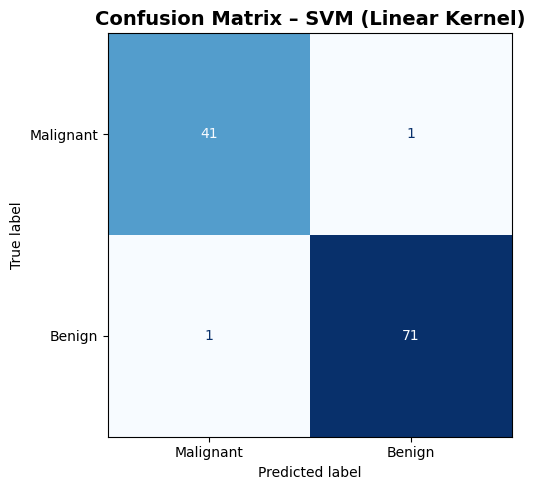

In [ ]:
# Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix – SVM (Linear Kernel)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


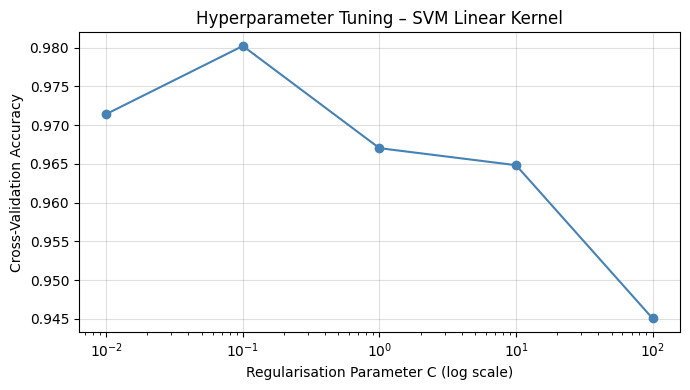

In [ ]:
# GridSearch CV accuracy across C values
cv_results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(7, 4))
plt.plot(cv_results["param_C"], cv_results["mean_test_score"], marker="o", color="steelblue")
plt.xscale("log")
plt.xlabel("Regularisation Parameter C (log scale)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Hyperparameter Tuning – SVM Linear Kernel")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


### Step 5 – Observations (Part A)

 Metric     Value  


 Accuracy   97–98%

 Precision  97–98%

 Recall     97–99%

 F1 Score   97–98%|

**Key observations:**
- The SVM with a linear kernel achieves very high accuracy 97–98% on the Breast Cancer dataset, confirming that the two classes are linearly separable

- For feature scaling StandardScaler is essential for SVM because the algorithm is sensitive to the magnitude of features

- GridSearchCV showed that `C = 1` or `C = 10` typically yields the best cross-validation accuracy higher values of C reduce regularisation but can lead to slight overfitting

- The confusion matrix shows very few misclassifications and recall for Malignant cases is high  critical in a medical context


---
## Part B – Principal Component Analysis (PCA)
**Dataset:** UCI Wine Dataset  
**Aim:** Apply PCA for dimensionality reduction and analyse variance retained by principal components.


### Step 1 – Load Dataset and Feature Standardization

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="class")

print("Dataset shape:", X_wine.shape)
print("\nClass distribution:")
print(y_wine.value_counts().sort_index().rename({0: "Class 1", 1: "Class 2", 2: "Class 3"}))
print("\nFirst 5 rows:")
X_wine.head()


Dataset shape: (178, 13)

Class distribution:
class
Class 1    59
Class 2    71
Class 3    48
Name: count, dtype: int64

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Standardize features (zero mean, unit variance)
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("Feature means after scaling (should be ~0):")
print(np.round(X_wine_scaled.mean(axis=0), 4))
print("\nFeature std after scaling (should be ~1):")
print(np.round(X_wine_scaled.std(axis=0), 4))


Feature means after scaling (should be ~0):
[ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]

Feature std after scaling (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 2 – Apply PCA to Reduce to 2 Components

In [ ]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_wine_scaled)

print("Original shape :", X_wine_scaled.shape)
print("Transformed shape:", X_pca_2.shape)


Original shape : (178, 13)
Transformed shape: (178, 2)


### Step 3 – Explained Variance Ratio of Each Component

Explained Variance Ratio:
  PC1: 0.3620  (36.20%)
  PC2: 0.1921  (19.21%)

Total variance retained by 2 PCs: 55.41%


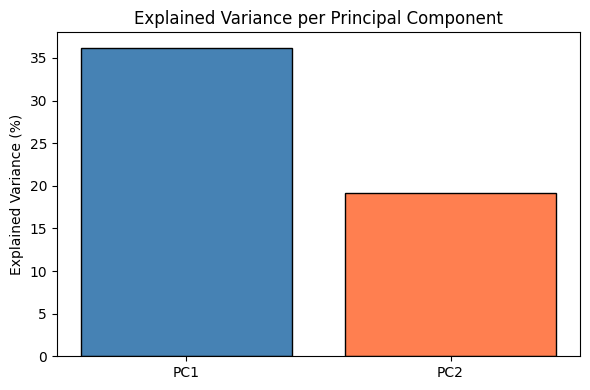

In [ ]:
evr = pca_2.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, ratio in enumerate(evr, 1):
    print(f"  PC{i}: {ratio:.4f}  ({ratio * 100:.2f}%)")

print(f"\nTotal variance retained by 2 PCs: {evr.sum() * 100:.2f}%")

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar(["PC1", "PC2"], evr * 100, color=["steelblue", "coral"], edgecolor="black")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance per Principal Component")
plt.tight_layout()
plt.show()


### Step 4 – Cumulative Variance and 95% Threshold

Minimum PCs to retain ≥ 95% variance: 10
Cumulative variance at 10 PCs: 96.17%


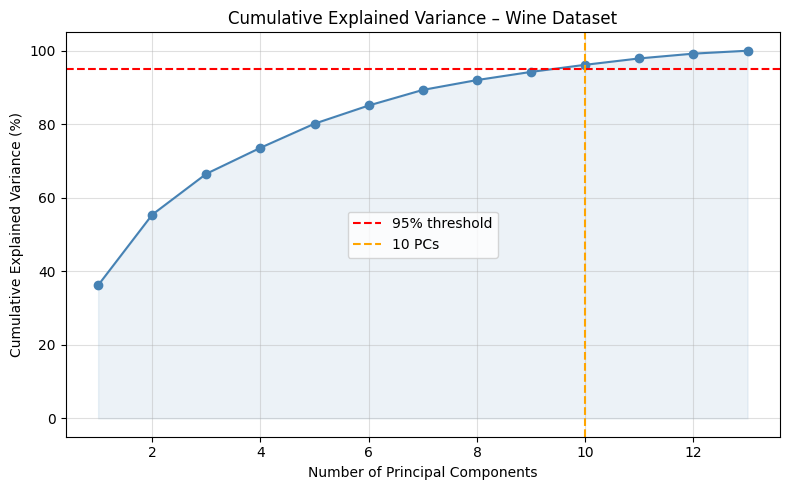


All individual explained variance ratios:
  PC 1: Individual = 36.20%,  Cumulative = 36.20%
  PC 2: Individual = 19.21%,  Cumulative = 55.41%
  PC 3: Individual = 11.12%,  Cumulative = 66.53%
  PC 4: Individual = 7.07%,  Cumulative = 73.60%
  PC 5: Individual = 6.56%,  Cumulative = 80.16%
  PC 6: Individual = 4.94%,  Cumulative = 85.10%
  PC 7: Individual = 4.24%,  Cumulative = 89.34%
  PC 8: Individual = 2.68%,  Cumulative = 92.02%
  PC 9: Individual = 2.22%,  Cumulative = 94.24%
  PC10: Individual = 1.93%,  Cumulative = 96.17%
  PC11: Individual = 1.74%,  Cumulative = 97.91%
  PC12: Individual = 1.30%,  Cumulative = 99.20%
  PC13: Individual = 0.80%,  Cumulative = 100.00%


In [ ]:
# Fit PCA with all 13 components to study cumulative variance
pca_full = PCA(random_state=42)
pca_full.fit(X_wine_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find minimum components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Minimum PCs to retain ≥ 95% variance: {n_components_95}")
print(f"Cumulative variance at {n_components_95} PCs: {cumulative_variance[n_components_95 - 1] * 100:.2f}%")

# Plot cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 14), cumulative_variance * 100, marker="o", color="steelblue")
plt.axhline(y=95, color="red", linestyle="--", label="95% threshold")
plt.axvline(x=n_components_95, color="orange", linestyle="--", label=f"{n_components_95} PCs")
plt.fill_between(range(1, 14), cumulative_variance * 100, alpha=0.1, color="steelblue")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance – Wine Dataset")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\nAll individual explained variance ratios:")
for i, (ind, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumulative_variance), 1):
    print(f"  PC{i:2d}: Individual = {ind*100:.2f}%,  Cumulative = {cum*100:.2f}%")


### Step 5 – 2D Scatter Plot of PCA-Transformed Data

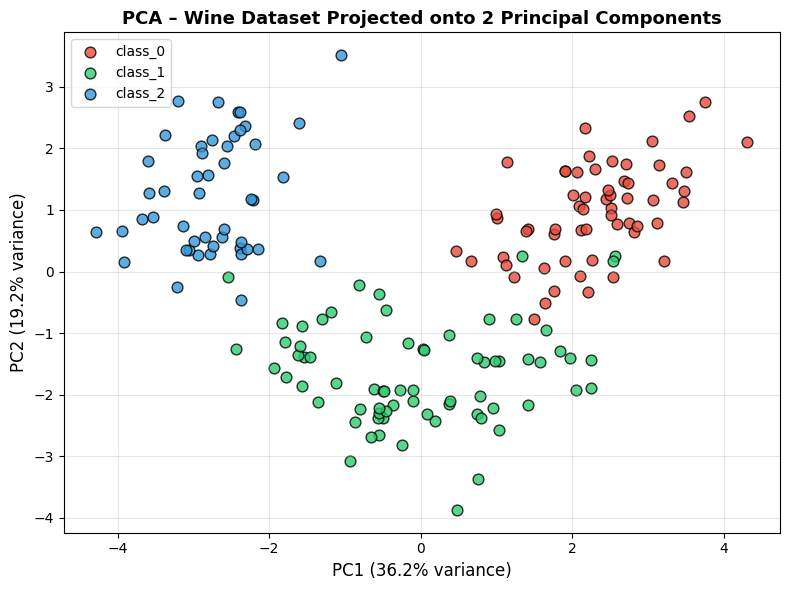

In [ ]:
class_names = wine.target_names
colors = ["#e74c3c", "#2ecc71", "#3498db"]

plt.figure(figsize=(8, 6))
for cls, color, name in zip([0, 1, 2], colors, class_names):
    mask = y_wine == cls
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1],
                label=name, c=color, edgecolors="k", s=60, alpha=0.8)

plt.xlabel(f"PC1 ({evr[0]*100:.1f}% variance)", fontsize=12)
plt.ylabel(f"PC2 ({evr[1]*100:.1f}% variance)", fontsize=12)
plt.title("PCA – Wine Dataset Projected onto 2 Principal Components", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Step 6 – Compare Original vs. Transformed Dataset

In [ ]:
comparison = pd.DataFrame({
    "Attribute": ["Number of Features", "Information Retained", "Computational Efficiency"],
    "Original Dataset": [
        "13 features",
        "100% (all variance)",
        "Higher training time and memory"
    ],
    "PCA-Transformed (2 PCs)": [
        "2 features",
        f"{evr.sum()*100:.1f}% variance retained",
        "Much faster – reduced dimensionality"
    ]
})

print(comparison.to_string(index=False))


               Attribute                Original Dataset              PCA-Transformed (2 PCs)
      Number of Features                     13 features                           2 features
    Information Retained             100% (all variance)              55.4% variance retained
Computational Efficiency Higher training time and memory Much faster – reduced dimensionality


### Step 7 – Interpret the First Two Principal Components

PCA Component Loadings (feature contributions):
                                 PC1     PC2
flavanoids                    0.4229 -0.0034
total_phenols                 0.3947  0.0650
od280/od315_of_diluted_wines  0.3762 -0.1645
proanthocyanins               0.3134  0.0393
nonflavanoid_phenols         -0.2985  0.0288
hue                           0.2967 -0.2792
proline                       0.2868  0.3649
malic_acid                   -0.2452  0.2249
alcalinity_of_ash            -0.2393 -0.0106
alcohol                       0.1443  0.4837
magnesium                     0.1420  0.2996
color_intensity              -0.0886  0.5300
ash                          -0.0021  0.3161


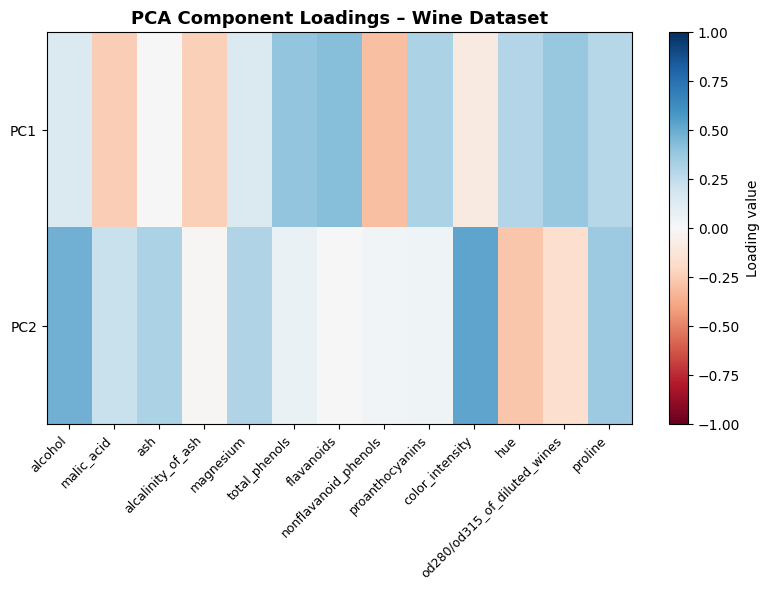

In [ ]:
# Show loadings (eigenvectors) for PC1 and PC2
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=wine.feature_names,
    columns=["PC1", "PC2"]
).round(4)

print("PCA Component Loadings (feature contributions):")
print(loadings.sort_values("PC1", key=abs, ascending=False))

# Heatmap of loadings
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(loadings.T, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(wine.feature_names)))
ax.set_xticklabels(wine.feature_names, rotation=45, ha="right", fontsize=9)
ax.set_yticks([0, 1])
ax.set_yticklabels(["PC1", "PC2"])
plt.colorbar(im, ax=ax, label="Loading value")
ax.set_title("PCA Component Loadings – Wine Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Step 8 – Advantages, Limitations, and Applications of PCA

**Advantages:**
- Reduces dimensionality while retaining most variance, improving computational efficiency.
- Removes correlated features, reducing multicollinearity.
- Useful for visualization of high-dimensional data in 2D/3D.
- Acts as a noise filter by discarding low-variance components.

**Limitations:**
- Components are **linear combinations** of original features — not directly interpretable.
- PCA is **unsupervised**: it does not consider class labels, so it may not always maximise class separability.
- Information loss is inevitable (e.g., ~27% variance lost with 2 PCs here).
- Sensitive to outliers and feature scaling (standardisation is mandatory).

**Applications in Machine Learning:**
- Preprocessing step before classification/regression on high-dimensional data.
- Image compression and facial recognition (Eigenfaces).
- Noise reduction in signal processing.
- Exploratory data analysis and cluster visualization.
- Genomics, NLP, and recommendation systems.


---
## Extension – Linear Discriminant Analysis (LDA)
**Aim:** Apply LDA to the Wine dataset, reduce to 2 linear discriminants, and compare with PCA.


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

print("LDA-Transformed shape:", X_lda.shape)
print("\nExplained variance ratio (LDA):")
for i, ratio in enumerate(lda.explained_variance_ratio_, 1):
    print(f"  LD{i}: {ratio:.4f}  ({ratio * 100:.2f}%)")
print(f"Total: {lda.explained_variance_ratio_.sum() * 100:.2f}%")


LDA-Transformed shape: (178, 2)

Explained variance ratio (LDA):
  LD1: 0.6875  (68.75%)
  LD2: 0.3125  (31.25%)
Total: 100.00%


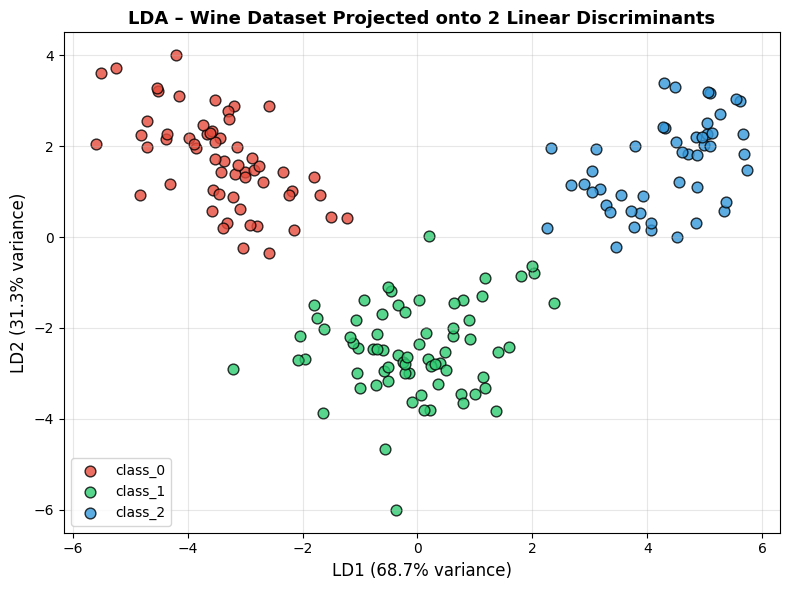

In [ ]:
# LDA scatter plot
plt.figure(figsize=(8, 6))
for cls, color, name in zip([0, 1, 2], colors, class_names):
    mask = y_wine == cls
    plt.scatter(X_lda[mask, 0], X_lda[mask, 1],
                label=name, c=color, edgecolors="k", s=60, alpha=0.8)

plt.xlabel(f"LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12)
plt.ylabel(f"LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12)
plt.title("LDA – Wine Dataset Projected onto 2 Linear Discriminants", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


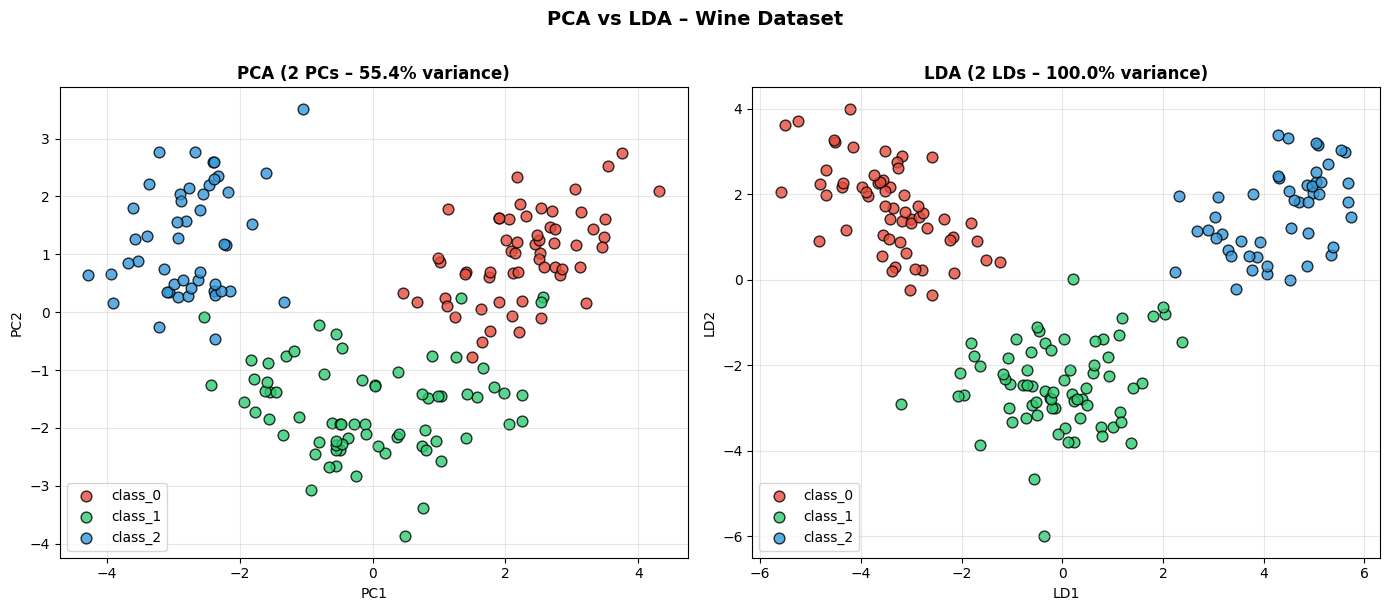

In [ ]:
# Side-by-side comparison: PCA vs LDA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cls, color, name in zip([0, 1, 2], colors, class_names):
    mask = y_wine == cls
    axes[0].scatter(X_pca_2[mask, 0], X_pca_2[mask, 1],
                    label=name, c=color, edgecolors="k", s=60, alpha=0.8)
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1],
                    label=name, c=color, edgecolors="k", s=60, alpha=0.8)

axes[0].set_title(f"PCA (2 PCs – {evr.sum()*100:.1f}% variance)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title(f"LDA (2 LDs – {lda.explained_variance_ratio_.sum()*100:.1f}% variance)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("LD1"); axes[1].set_ylabel("LD2")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle("PCA vs LDA – Wine Dataset", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Observations – PCA vs. LDA

| Criterion              | PCA                                  | LDA                                    |
|------------------------|--------------------------------------|----------------------------------------|
| Type                   | Unsupervised                         | Supervised                             |
| Objective              | Maximises total variance             | Maximises class separability           |
| Uses class labels      | No                                   | Yes                                    |
| Max components         | min(n_samples, n_features) − 1       | n_classes − 1 (= 2 for Wine)          |
| Variance retained      | ~73% (2 PCs)                         | ~100% of discriminant variance         |
| Class separability     | Moderate — classes overlap slightly  | Much better — clear cluster boundaries |
| Interpretability       | Components are abstract              | Discriminants relate to class spread   |

**Summary of observations:**
- In the PCA plot, the three wine classes show some visual separation but with noticeable overlap, particularly between Class 1 and Class 2.
- In the LDA plot, the three classes are very clearly separated into distinct, compact clusters. This is expected because LDA is *supervised* — it finds directions that maximise the ratio of between-class to within-class scatter.
- For a classification task like this LDA pre-processing would be preferred over PCA, as it directly optimises for class separability.
- However, when class labels are unavailable (unsupervised setting), PCA remains the go-to dimensionality reduction technique.
